This shows the distibution of FiLM parameters , features before and after applying filM when the initial image is passed throught the image backbone EfficientNet followed by 4 FiLMed Resblock each consist of FiLM 

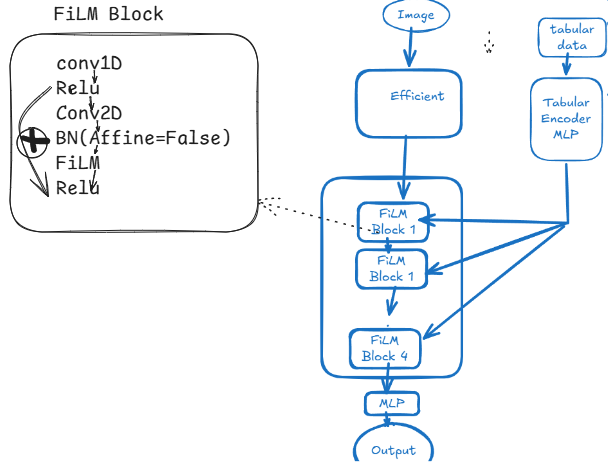

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [6]:
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gc.enable()
import torch

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../../.."
data_csv    = os.path.join(main_folder, "data", "train.csv")
img_folder  = os.path.join(main_folder, "data", "train")

# EXPERIMENT-SPECIFIC
cfg_key  = "exp12_film"  # or other key
exp_name = "exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone"
out_dir  = os.path.join(main_folder, "outputs", "extra", "exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone")

df  = pd.read_csv(data_csv)
TARGET   = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

cfg = EXP_CONFIGS[cfg_key].copy()
cfg["name"] = exp_name

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Experiment:", cfg["name"])
print("Out dir:", out_dir)

Device: cuda
Experiment: exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
Out dir: ../../../outputs/extra/exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone


In [7]:
oof_path = os.path.join(out_dir, "oof_detail.csv")
df_oof   = pd.read_csv(oof_path)

fold_rmse_list = []
for f in range(1, cfg["n_splits"] + 1):
    sub  = df_oof[df_oof.fold == f]
    rmse = ((sub.ytrue - sub.oof_pred) ** 2).mean() ** 0.5
    fold_rmse_list.append((f, rmse))
    print(f"Fold {f} OOF RMSE: {rmse:.4f} (n={len(sub)})")

best_fold, best_rmse = min(fold_rmse_list, key=lambda x: x[1])
print(f"\nBest fold: {best_fold} (OOF RMSE={best_rmse:.4f})")

Fold 1 OOF RMSE: 19.1770 (n=1983)
Fold 2 OOF RMSE: 18.9927 (n=1983)
Fold 3 OOF RMSE: 18.3068 (n=1982)
Fold 4 OOF RMSE: 18.5727 (n=1982)
Fold 5 OOF RMSE: 19.2491 (n=1982)

Best fold: 3 (OOF RMSE=18.3068)


In [8]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
from src.data import build_transforms, ImageTabDataset

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
splits = list(kf.split(df))
tr_idx, val_idx = splits[best_fold - 1]

val_df = df.iloc[val_idx].reset_index(drop=True)
val_tf = build_transforms(cfg["img_size"], cfg["aug"], train=False)
val_ds = ImageTabDataset(val_df, img_folder, tab_cols, val_tf)

val_loader = DataLoader(
    val_ds, batch_size=32, shuffle=False,
    num_workers=16, pin_memory=True,
)

print("Val size (best fold):", len(val_ds))

Val size (best fold): 1982


In [9]:
from src.film import FiLMExternalModulation

def build_best_model_external(cfg, tab_cols, best_fold, out_dir, device):
    model = FiLMExternalModulation(
        backbone_name        = cfg["backbone"],   # "efficientnet_b1" "
        tab_input_dim        = len(tab_cols),
        tab_hidden           = 64,                # match training (checkpoint)
        num_film_blocks      = 4,                 # same as training
        pretrained_backbone  = False,             # weights come from checkpoint
        freeze_backbone      = False,
        tab_encoder_capacity = "small",           
    )

    ckpt_path = os.path.join(out_dir, f"model_fold{best_fold}.pt")
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)
    model.to(device).eval()
    print("Loaded:", ckpt_path)
    return model
analysis_model = build_best_model_external(cfg, tab_cols, best_fold, out_dir, device)

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: ../../../outputs/extra/exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone/model_fold3.pt


In [10]:
from src.film_analysis import collect_film_stats

gamma, beta, feat_before, feat_after = collect_film_stats(
    analysis_model, val_loader, device, max_batches=None
)
print("FiLM blocks found:", sorted(gamma.keys()))

FiLM blocks found: [0, 1, 2, 3]


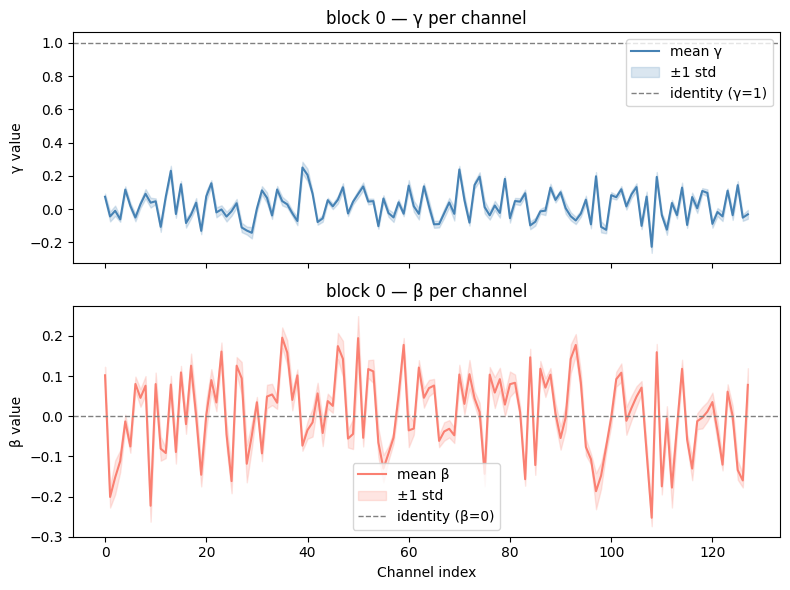

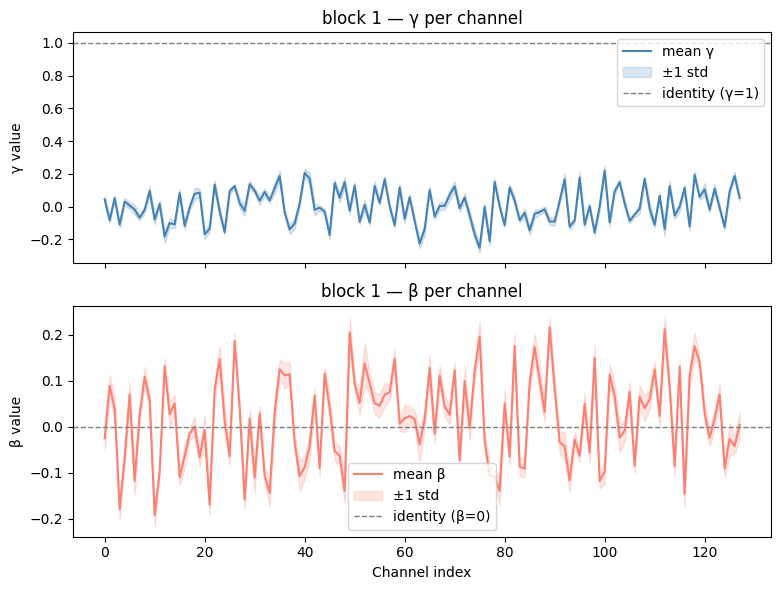

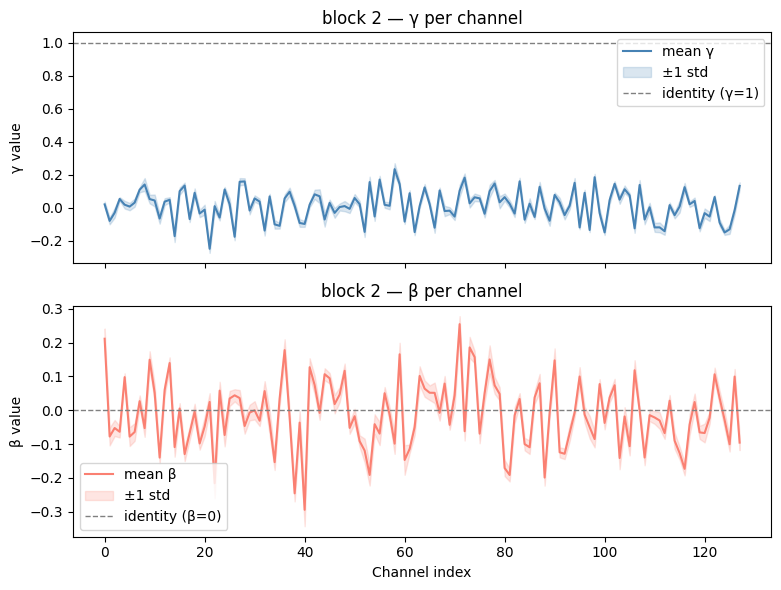

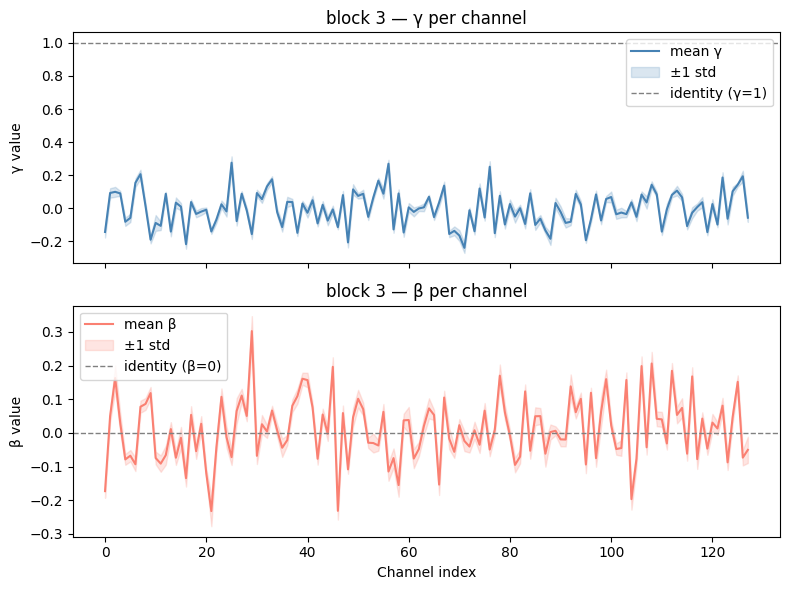

In [11]:
from src.film_analysis import plot_gamma_beta_per_channel

plot_gamma_beta_per_channel(
    gamma   = gamma,
    beta    = beta,
    exp_name = cfg["name"],
    out_dir  = out_dir,
)


[FiLM] Block 0  — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


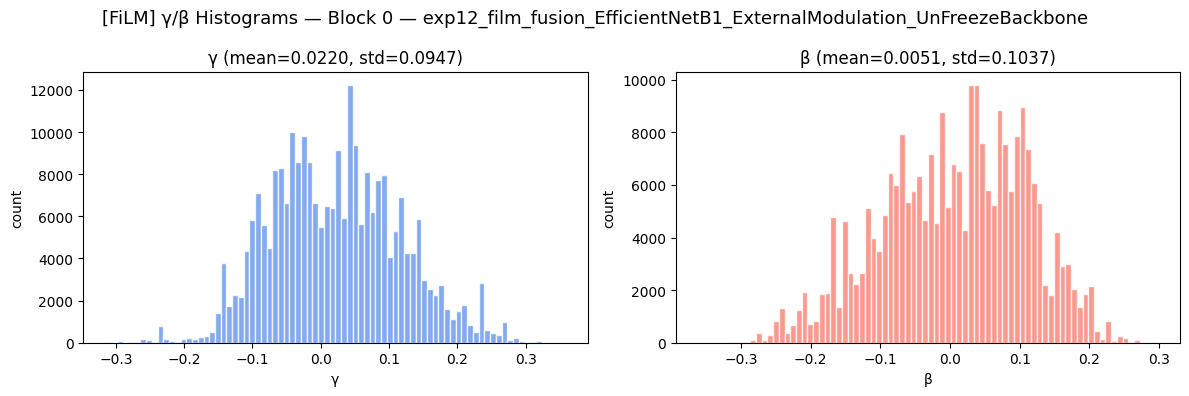

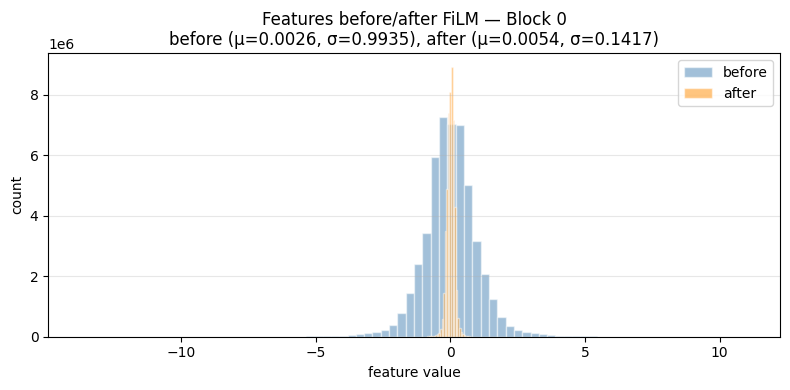

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,0,0,0,0,0,1.534243,0.190488,0.065545,0.089926,1.343755
1,0,0,0,0,1,1.007462,0.155960,0.065545,0.089926,0.851502
2,0,0,0,0,2,0.804062,0.142628,0.065545,0.089926,0.661434
3,0,0,0,0,3,0.669164,0.133787,0.065545,0.089926,0.535377
4,0,0,0,0,4,0.571103,0.127359,0.065545,0.089926,0.443743
...,...,...,...,...,...,...,...,...,...,...
16380,0,0,83,8,0,-1.153113,-0.274967,0.079156,-0.183692,0.878146
16381,0,0,83,8,1,-0.630970,-0.233637,0.079156,-0.183692,0.397333
16382,0,0,83,8,2,-0.289391,-0.206599,0.079156,-0.183692,0.082792
16383,0,0,83,8,3,0.040722,-0.180468,0.079156,-0.183692,0.221191


[FiLM] Block 0 global stats:
  L2 ||after - before|| = 6918.8003


,block_idx,which,min,max,mean,std
0,0,before,-13.702871,11.007028,0.002551,0.993473
1,0,after,-2.685485,2.027251,0.005425,0.141725



[FiLM] Block 1  — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


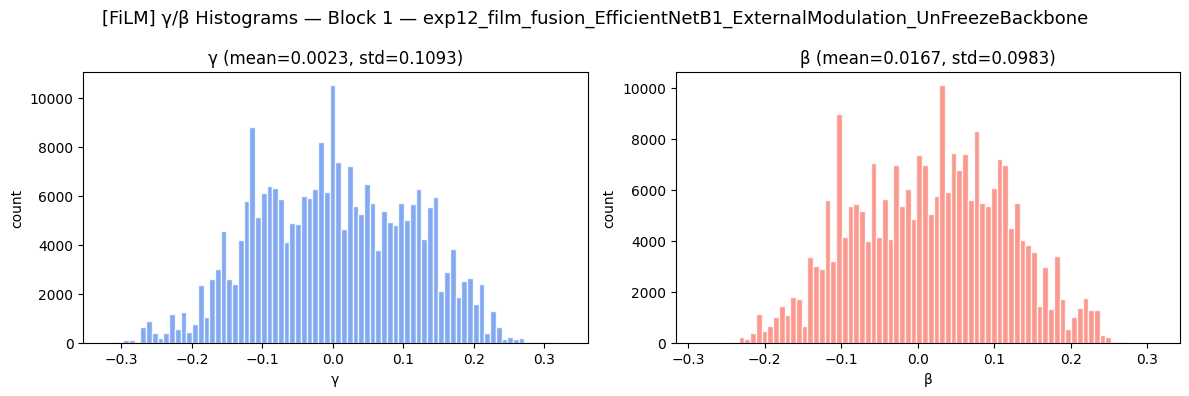

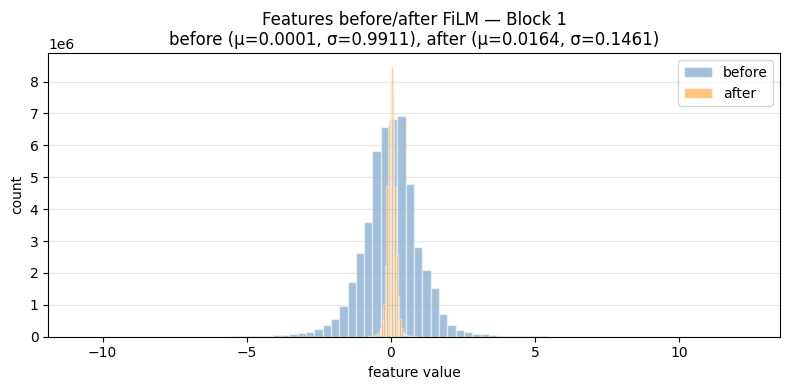

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,1,0,0,0,0,2.094777,0.150390,0.064110,0.016093,1.944386
1,1,0,0,0,1,1.357639,0.103132,0.064110,0.016093,1.254507
2,1,0,0,0,2,1.266054,0.097260,0.064110,0.016093,1.168793
3,1,0,0,0,3,1.227513,0.094790,0.064110,0.016093,1.132723
4,1,0,0,0,4,1.276909,0.097956,0.064110,0.016093,1.178952
...,...,...,...,...,...,...,...,...,...,...
16380,1,0,83,8,0,-1.806925,0.051909,-0.102177,-0.132718,1.858833
16381,1,0,83,8,1,-0.747194,-0.056371,-0.102177,-0.132718,0.690823
16382,1,0,83,8,2,-0.681777,-0.063056,-0.102177,-0.132718,0.618721
16383,1,0,83,8,3,-0.652610,-0.066036,-0.102177,-0.132718,0.586574


[FiLM] Block 1 global stats:
  L2 ||after - before|| = 7042.0688


,block_idx,which,min,max,mean,std
0,1,before,-10.734275,12.343852,0.000114,0.991100
1,1,after,-2.213482,2.349154,0.016355,0.146138



[FiLM] Block 2  — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


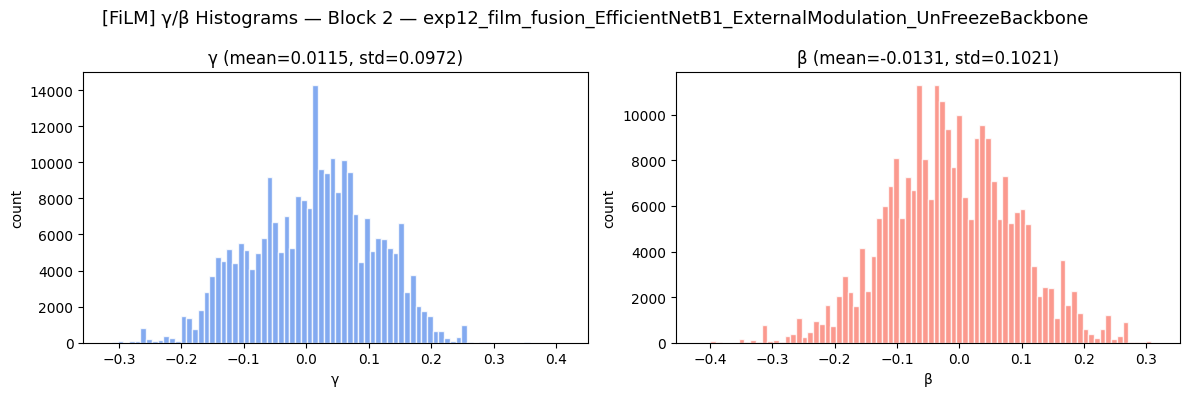

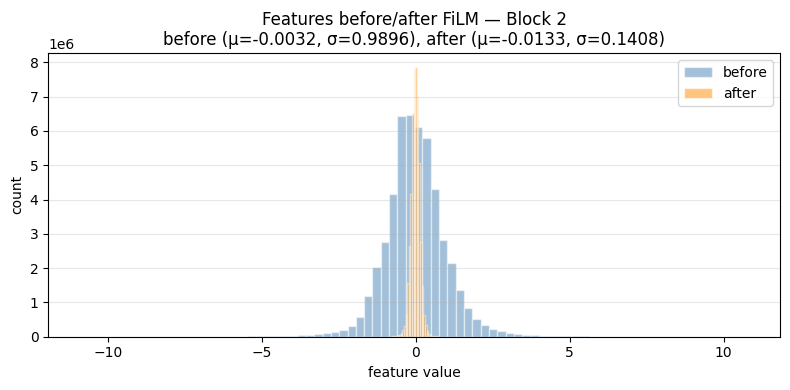

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,2,0,0,0,0,-1.460755,0.164416,0.026967,0.203808,1.625172
1,2,0,0,0,1,-1.595288,0.160788,0.026967,0.203808,1.756076
2,2,0,0,0,2,-1.476640,0.163988,0.026967,0.203808,1.640628
3,2,0,0,0,3,-1.381829,0.166544,0.026967,0.203808,1.548373
4,2,0,0,0,4,-1.325879,0.168053,0.026967,0.203808,1.493932
...,...,...,...,...,...,...,...,...,...,...
16380,2,0,83,8,0,0.907787,0.139605,0.133983,0.017977,0.768182
16381,2,0,83,8,1,0.466689,0.080505,0.133983,0.017977,0.386184
16382,2,0,83,8,2,0.070241,0.027388,0.133983,0.017977,0.042854
16383,2,0,83,8,3,-0.309561,-0.023499,0.133983,0.017977,0.286062


[FiLM] Block 2 global stats:
  L2 ||after - before|| = 6959.7573


,block_idx,which,min,max,mean,std
0,2,before,-10.858593,10.752854,-0.003210,0.989570
1,2,after,-2.319127,1.870130,-0.013288,0.140783



[FiLM] Block 3  — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


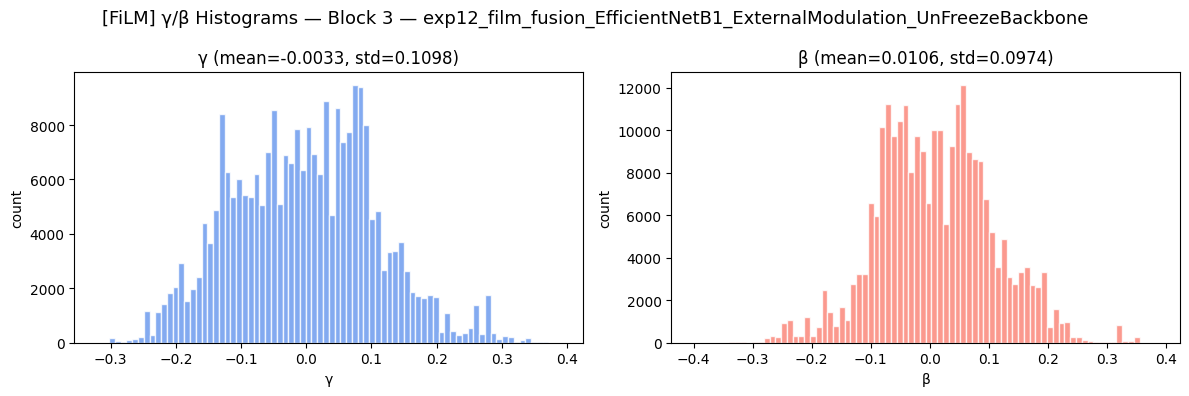

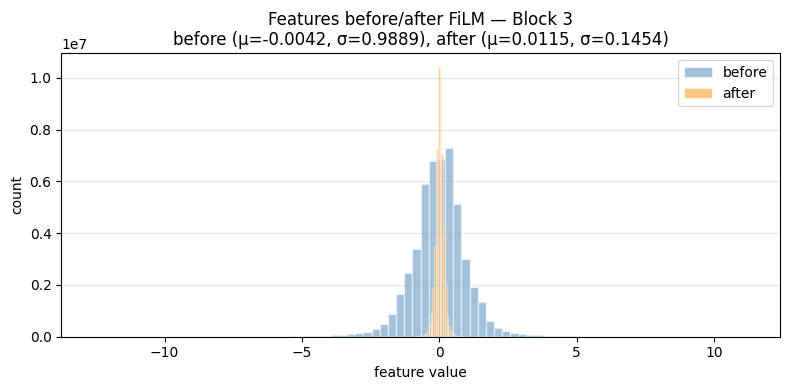

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,3,0,0,0,0,1.489424,-0.512134,-0.216231,-0.190074,2.001558
1,3,0,0,0,1,1.125286,-0.433396,-0.216231,-0.190074,1.558681
2,3,0,0,0,2,0.962825,-0.398267,-0.216231,-0.190074,1.361091
3,3,0,0,0,3,0.862654,-0.376606,-0.216231,-0.190074,1.239261
4,3,0,0,0,4,0.839143,-0.371523,-0.216231,-0.190074,1.210666
...,...,...,...,...,...,...,...,...,...,...
16380,3,0,83,8,0,1.311126,-0.060937,-0.151519,0.137723,1.372063
16381,3,0,83,8,1,0.653606,0.038689,-0.151519,0.137723,0.614917
16382,3,0,83,8,2,0.327420,0.088113,-0.151519,0.137723,0.239307
16383,3,0,83,8,3,0.032169,0.132849,-0.151519,0.137723,0.100680


[FiLM] Block 3 global stats:
  L2 ||after - before|| = 7069.5308


,block_idx,which,min,max,mean,std
0,3,before,-12.568098,11.212448,-0.004196,0.988908
1,3,after,-2.461577,2.742362,0.011466,0.145405


In [12]:
from src.film_analysis import analyze_film_per_block

analyze_film_per_block(
    gamma       = gamma,
    beta        = beta,
    feat_before = feat_before, #feature before FiLM 
    feat_after  = feat_after, # feature after FiLM 
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    n_table_rows = 16385, 
)


[FiLM per-channel] Block 0 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


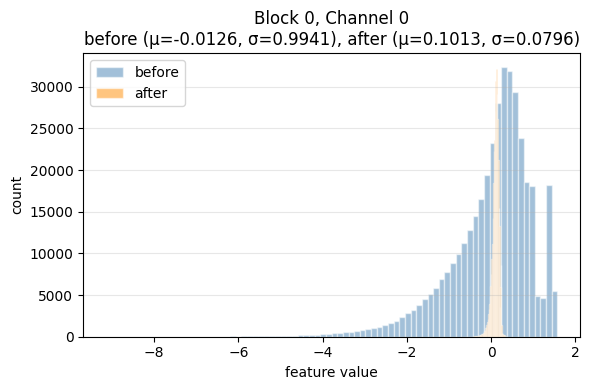

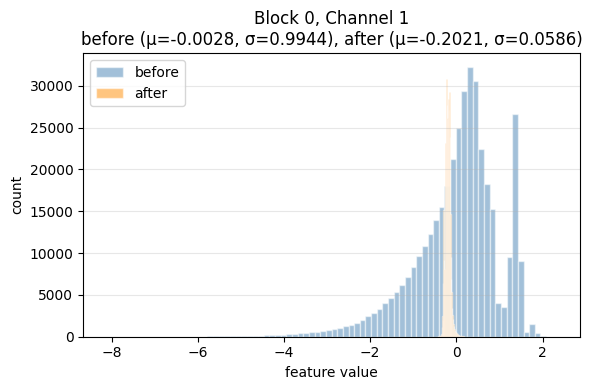

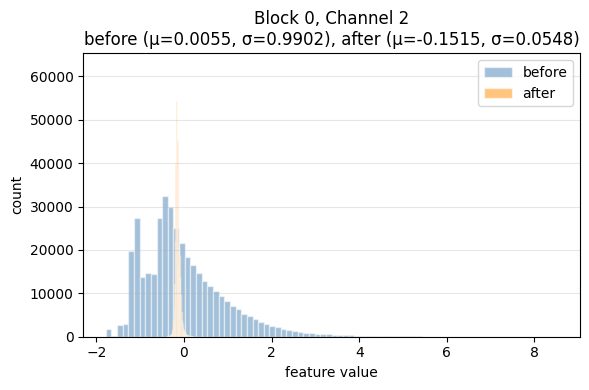

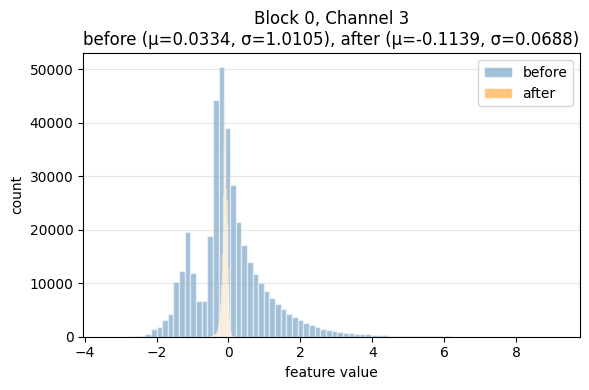


[FiLM per-channel] Block 1 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


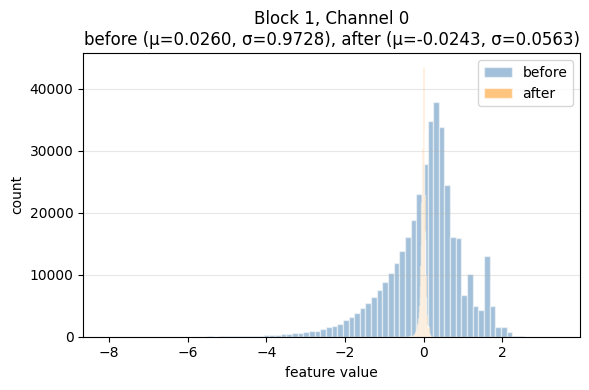

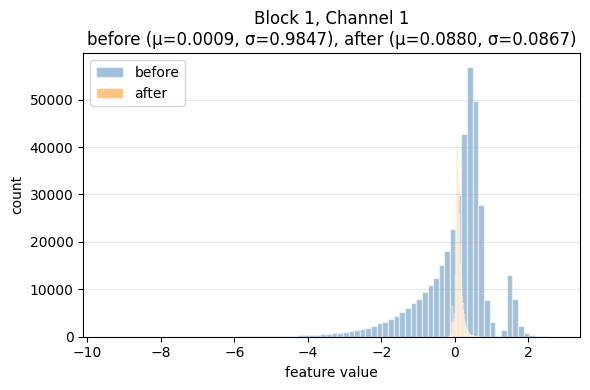

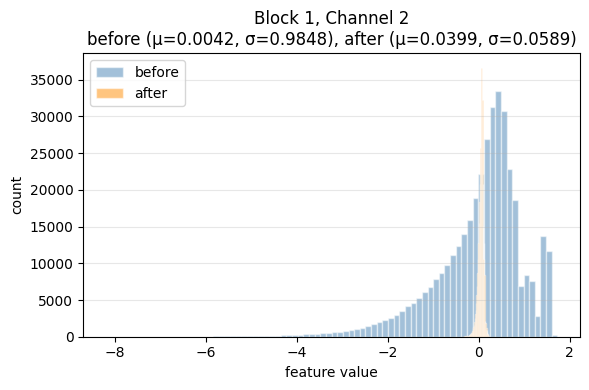

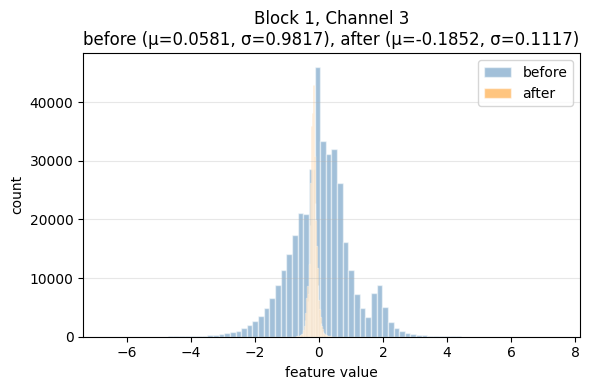


[FiLM per-channel] Block 2 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


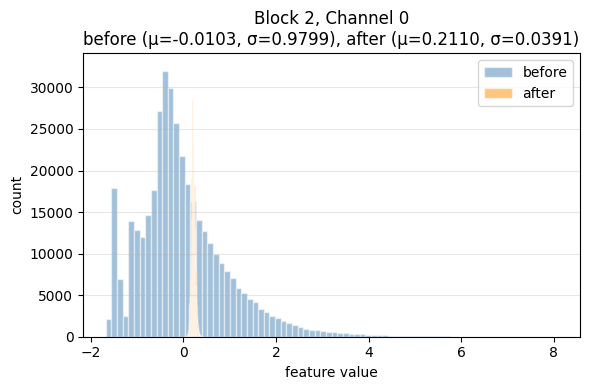

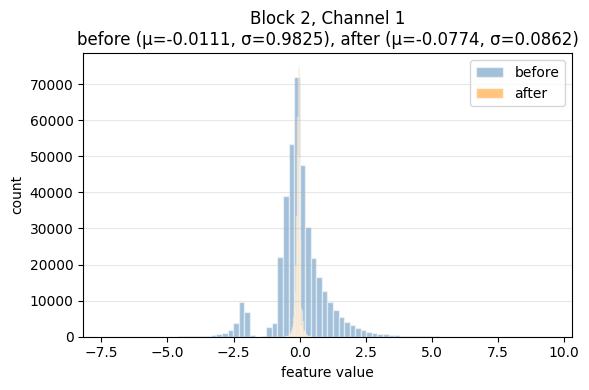

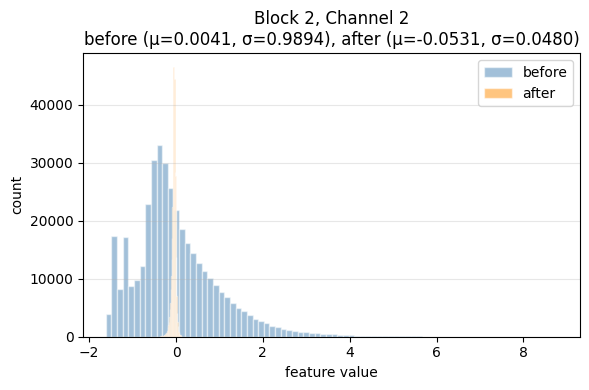

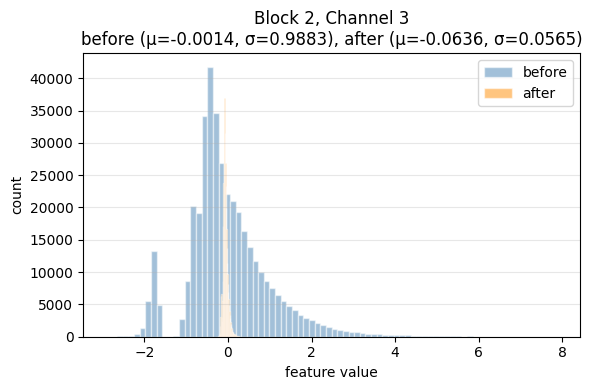


[FiLM per-channel] Block 3 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


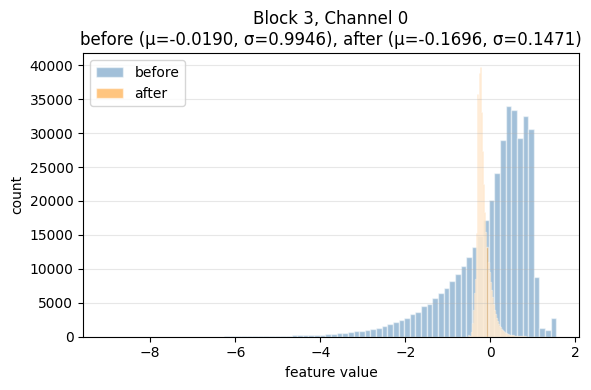

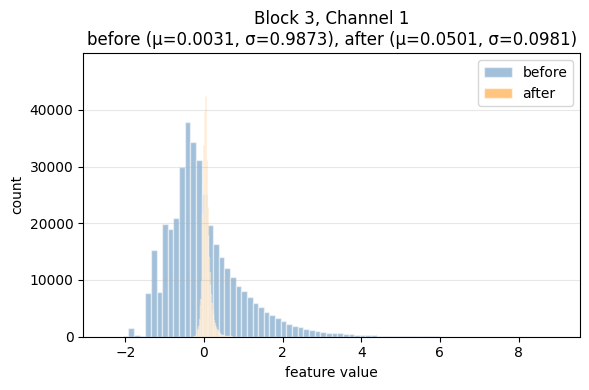

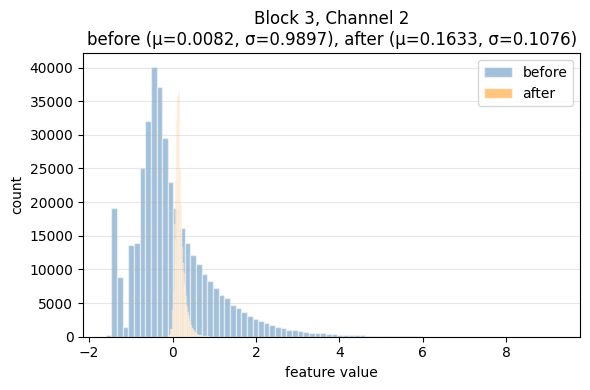

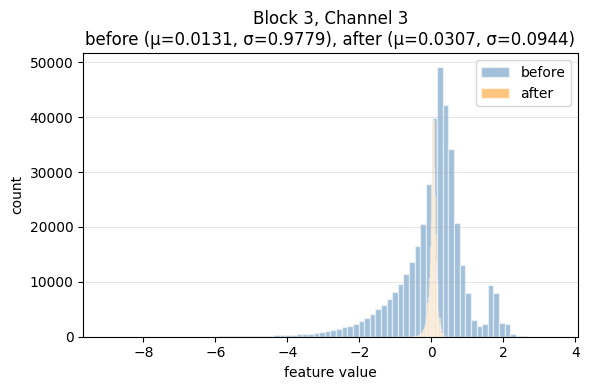

In [13]:
from src.film_analysis import analyze_film_per_channel
analyze_film_per_channel(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_channels = 4,   # e.g. first 4 channels
)


[FiLM per-sample] Block 0 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


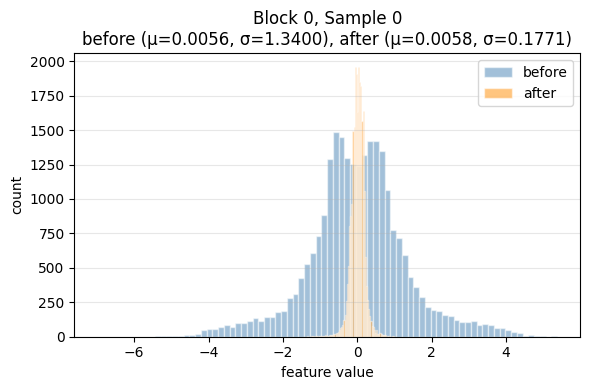

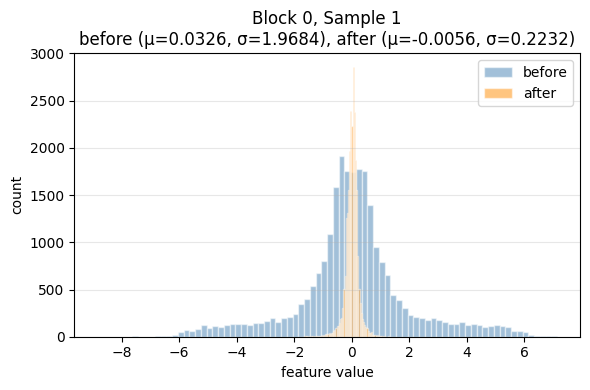

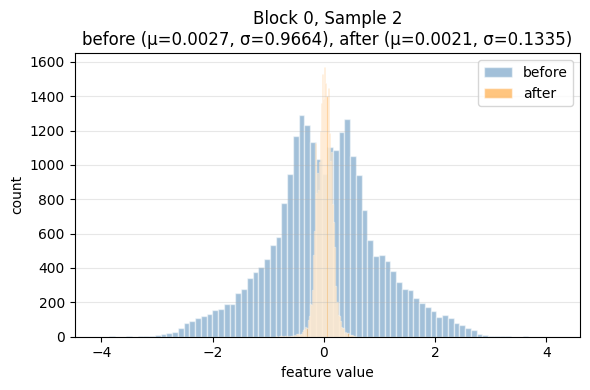

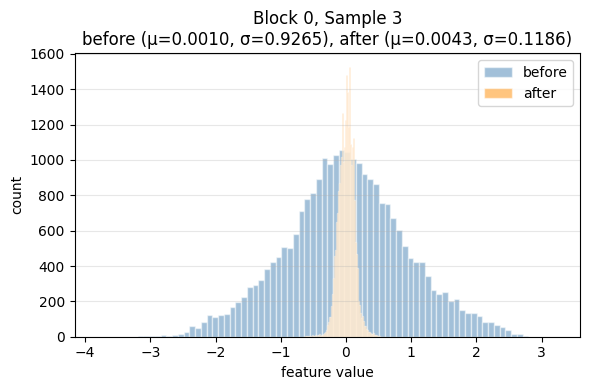


[FiLM per-sample] Block 1 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


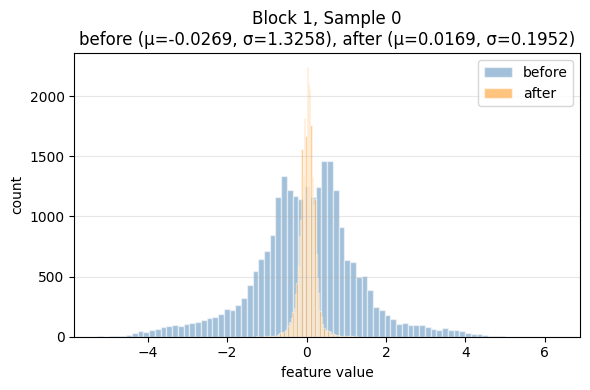

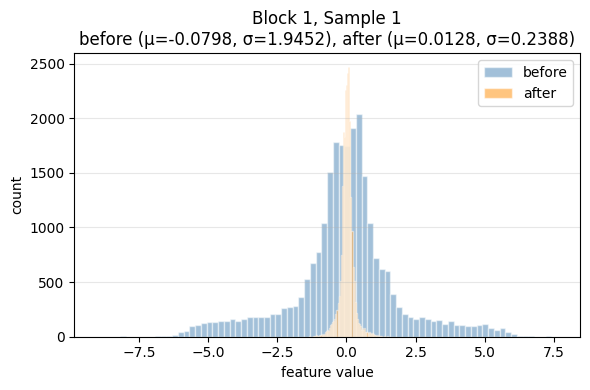

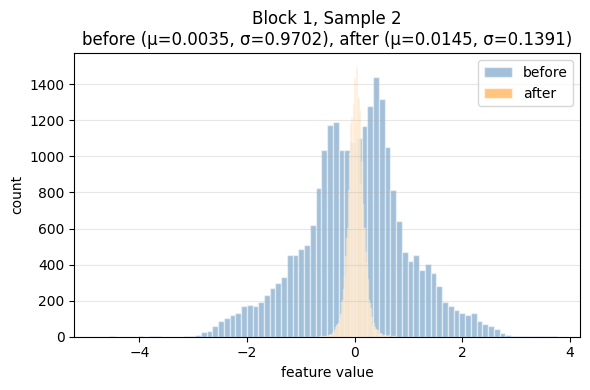

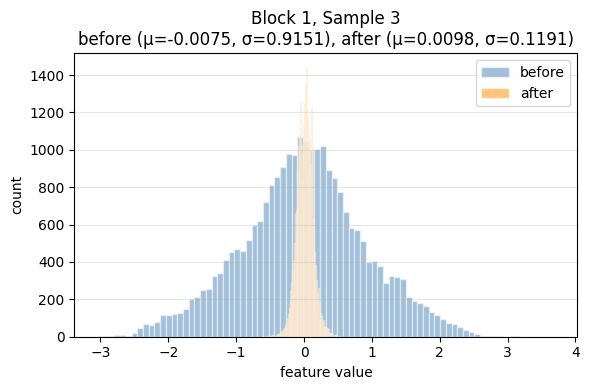


[FiLM per-sample] Block 2 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


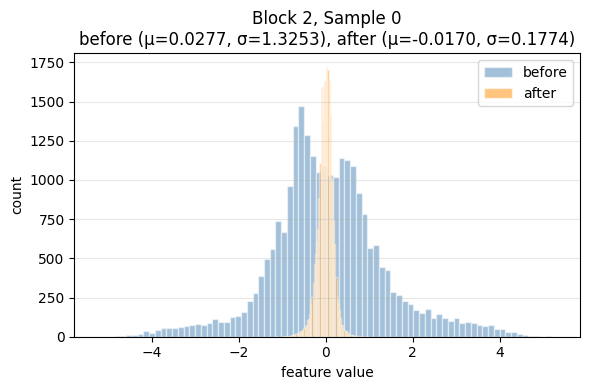

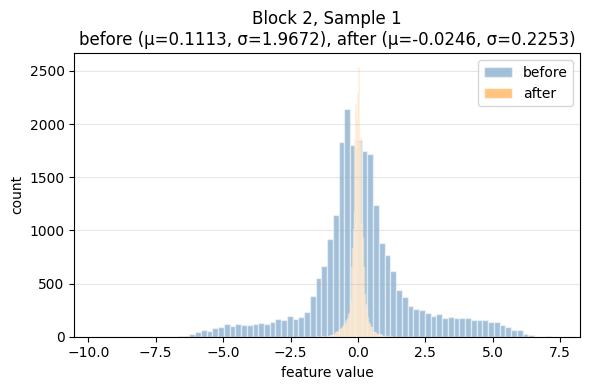

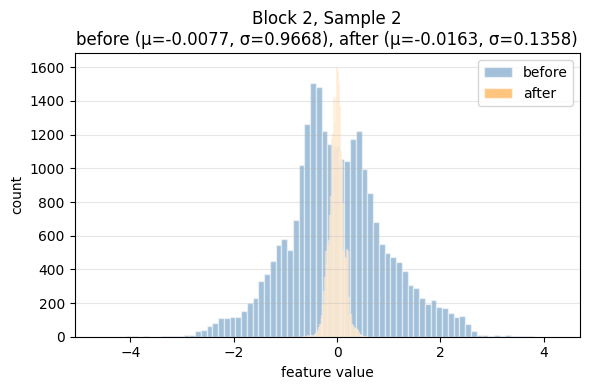

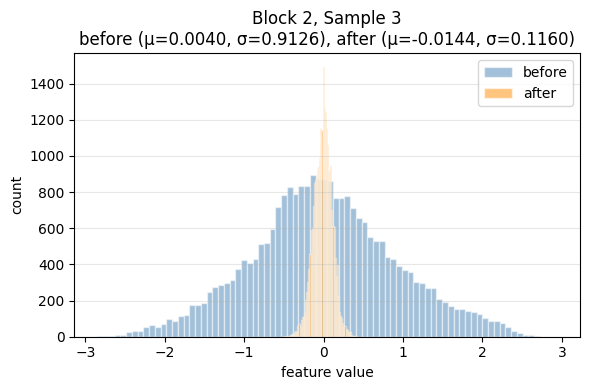


[FiLM per-sample] Block 3 — exp12_film_fusion_EfficientNetB1_ExternalModulation_UnFreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


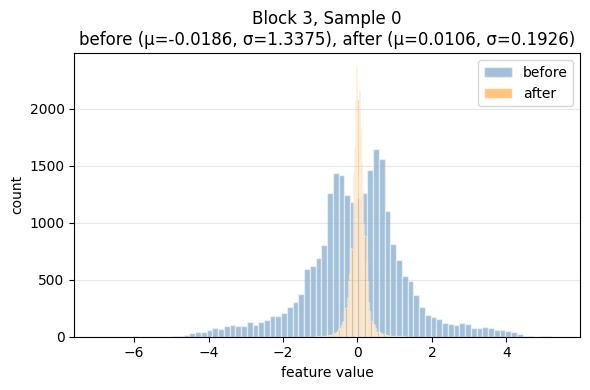

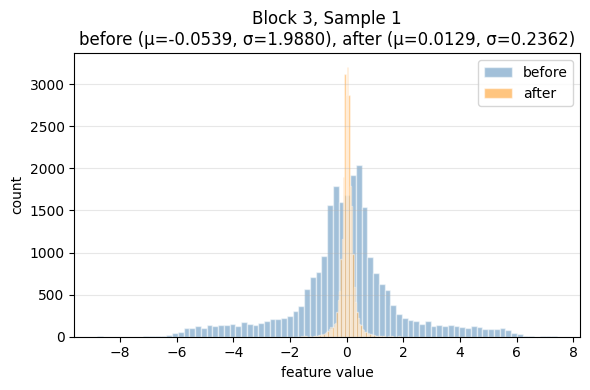

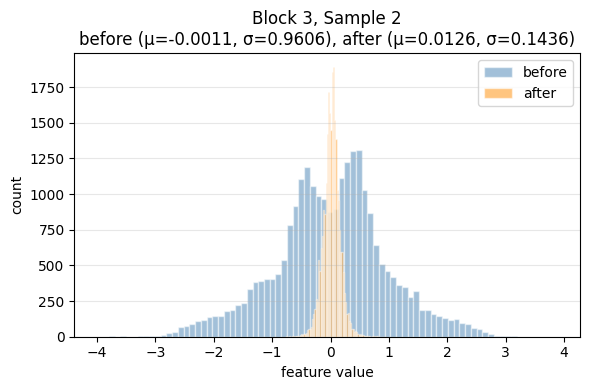

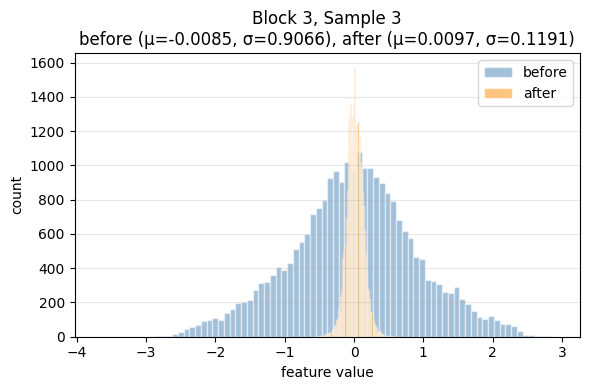

In [14]:
from src.film_analysis import analyze_film_per_sample
analyze_film_per_sample(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_samples = 4,   # e.g. first 4 samples
)